In [3]:
from google.colab import files
uploaded = files.upload()

Saving climate_headlines_sentiment.csv to climate_headlines_sentiment (2).csv


In [4]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,Sr. No,Headline,Link,Content,Sentiment,Justification
0,0,Australia's year ahead in climate and environm...,https://www.abc.net.au/news/science/2024-01-23...,The year has barely started and extreme weath...,0.0,The headline is unclear about its direct impac...
1,1,Projections reveal the vulnerability of freshw...,https://news.griffith.edu.au/2024/01/09/projec...,"“Water from groundwater, rivers and rainfall ...",-0.5,The vulnerability of freshwater is concerning ...
2,2,"Record heat in 2023 worsened global droughts, ...",https://www.anu.edu.au/news/all-news/record-he...,2023 saw an increase in the frequency and int...,-1.0,The headline describes worsening environmental...
3,3,"It's not just the total rainfall ""“ why is eas...",https://www.theguardian.com/australia-news/202...,The number of storms in some regions is decre...,0.0,The headline is unclear about its stance on cl...
4,4,Expert Commentary: 2023 was the warmest year o...,https://www.csiro.au/en/news/all/news/2024/jan...,The European Union's Copernicus Climate Chang...,-0.5,While highlighting the reality of climate chan...


In [5]:
uploaded.keys()

dict_keys(['climate_headlines_sentiment (2).csv'])

In [7]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sr. No         1024 non-null   int64  
 1   Headline       1024 non-null   object 
 2   Link           1024 non-null   object 
 3   Content        1024 non-null   object 
 4   Sentiment      1023 non-null   float64
 5   Justification  1023 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 48.1+ KB


In [8]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1023 entries, 0 to 1023
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sr. No         1023 non-null   int64  
 1   Headline       1023 non-null   object 
 2   Link           1023 non-null   object 
 3   Content        1023 non-null   object 
 4   Sentiment      1023 non-null   float64
 5   Justification  1023 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 55.9+ KB


In [9]:
df['Sentiment'] = df['Sentiment'].astype(int)
df['Sentiment'].value_counts()

,count
Sentiment,
0,596
-1,275
1,152


In [10]:
df['Sentiment'].unique()

array([ 0, -1,  1])

In [11]:
df = df[['Content', 'Sentiment', 'Headline']]
df.head()

,Content,Sentiment,Headline
0,The year has barely started and extreme weath...,0,Australia's year ahead in climate and environm...
1,"“Water from groundwater, rivers and rainfall ...",0,Projections reveal the vulnerability of freshw...
2,2023 saw an increase in the frequency and int...,-1,"Record heat in 2023 worsened global droughts, ..."
3,The number of storms in some regions is decre...,0,"It's not just the total rainfall ""“ why is eas..."
4,The European Union's Copernicus Climate Chang...,0,Expert Commentary: 2023 was the warmest year o...


In [12]:
df.head()
df['Sentiment'].value_counts()

,count
Sentiment,
0,596
-1,275
1,152


In [23]:
from sklearn.utils import resample

df_majority = df[df['Sentiment'] == 0]
df_minority_pos = df[df['Sentiment'] == 1]
df_minority_neg = df[df['Sentiment'] == -1]

df_minority_pos_upsampled = resample(df_minority_pos,
                                     replace=True,
                                     n_samples=596,
                                     random_state=42)

df_minority_neg_upsampled = resample(df_minority_neg,
                                     replace=True,
                                     n_samples=596,
                                     random_state=42)

df_balanced = pd.concat([df_majority, df_minority_pos_upsampled, df_minority_neg_upsampled])

In [24]:
df_balanced

,Content,Sentiment,Headline,cleaned
0,The year has barely started and extreme weath...,0,Australia's year ahead in climate and environm...,year barely started extreme weather events alr...
1,"“Water from groundwater, rivers and rainfall ...",0,Projections reveal the vulnerability of freshw...,water groundwater rivers rainfall undergoing d...
3,The number of storms in some regions is decre...,0,"It's not just the total rainfall ""“ why is eas...",number storms regions decreasing intensity rai...
4,The European Union's Copernicus Climate Chang...,0,Expert Commentary: 2023 was the warmest year o...,european union copernicus climate change servi...
5,Climate change is increasing the risks of ext...,0,"Climate migration ""“ News, Research and Analys...",climate change increasing risks extreme heat f...
...,...,...,...,...
345,According to a survey by the newspaper O Glob...,-1,Social issues led Brazil to miss the boat on c...,according survey newspaper globo brazil state ...
886,Climate change had a role in making the storm...,-1,Scientists say climate change made Spanish flo...,climate change role making storm hit spain int...
899,The UK has cut emissions by half since 1990 a...,-1,UK ramps up climate action under new leadershi...,uk cut emissions half since line carbon budget...
193,"Extreme heat, drought, wildfires, and floodin...",-1,Europe is not prepared for rapidly growing cli...,extreme heat drought wildfires flooding experi...


In [28]:
import nltk
nltk.download('stopwords')

import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['cleaned'] = df['Content'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,2),   # bigrams added
    min_df=2
)

X = tfidf.fit_transform(df_balanced['cleaned'])
y = df_balanced['Sentiment']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [35]:
df[['Content', 'cleaned']].head()

,Content,cleaned
0,The year has barely started and extreme weath...,year barely started extreme weather events alr...
1,"“Water from groundwater, rivers and rainfall ...",water groundwater rivers rainfall undergoing d...
2,2023 saw an increase in the frequency and int...,saw increase frequency intensity rainfall even...
3,The number of storms in some regions is decre...,number storms regions decreasing intensity rai...
4,The European Union's Copernicus Climate Chang...,european union copernicus climate change servi...


In [43]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8296089385474861


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.85      0.81      0.83       117
           0       0.82      0.74      0.78       128
           1       0.82      0.95      0.88       113

    accuracy                           0.83       358
   macro avg       0.83      0.83      0.83       358
weighted avg       0.83      0.83      0.83       358



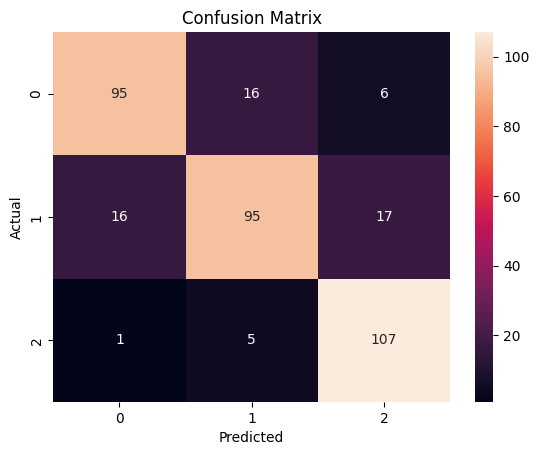

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [46]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8379888268156425


**Visualization**

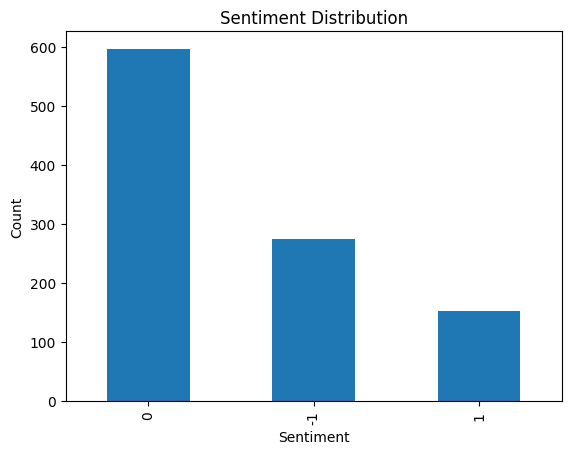

In [47]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

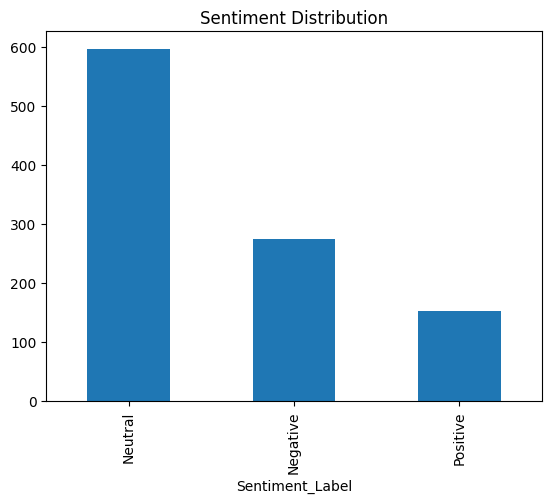

In [48]:
label_map = {-1: "Negative", 0: "Neutral", 1: "Positive"}
df['Sentiment_Label'] = df['Sentiment'].map(label_map)

df['Sentiment_Label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

In [49]:
!pip install wordcloud
from wordcloud import WordCloud

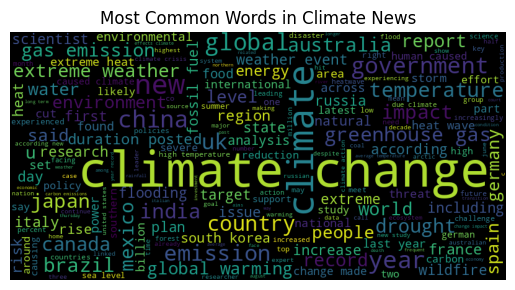

In [50]:
text = " ".join(df['cleaned'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in Climate News")
plt.show()

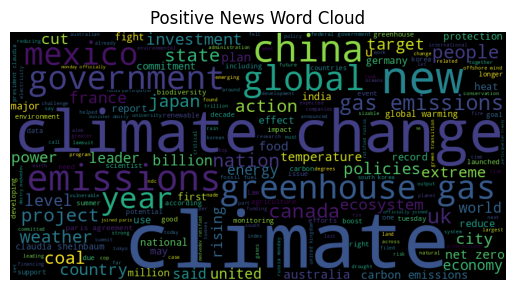

In [51]:
pos_text = " ".join(df[df['Sentiment']==1]['cleaned'])

wordcloud = WordCloud(width=800, height=400).generate(pos_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive News Word Cloud")
plt.show()

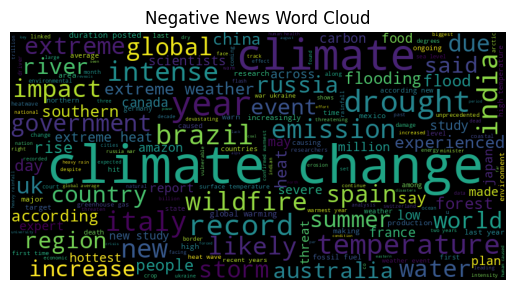

In [52]:
neg_text = " ".join(df[df['Sentiment']==-1]['cleaned'])

wordcloud = WordCloud(width=800, height=400).generate(neg_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative News Word Cloud")
plt.show()

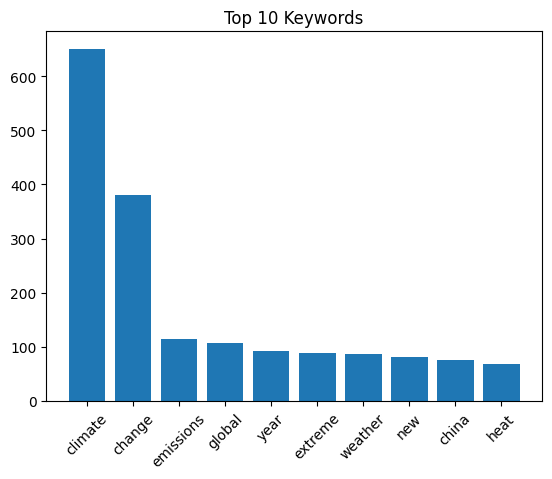

In [53]:
from collections import Counter

all_words = " ".join(df['cleaned']).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Keywords")
plt.show()

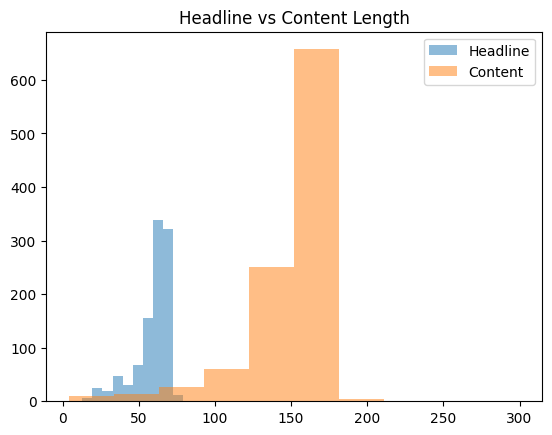

In [57]:
df['headline_length'] = df['Headline'].apply(len)
df['content_length'] = df['Content'].apply(len)

plt.hist(df['headline_length'], alpha=0.5, label='Headline')
plt.hist(df['content_length'], alpha=0.5, label='Content')
plt.legend()
plt.title("Headline vs Content Length")
plt.show()